1. Credit Card Dataset Overview

In [29]:
import sys
!{sys.executable} -m pip install matplotlib seaborn pandas
import warnings
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('fraudTrain.csv', sep=';')

df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,01.01.2019 00:00,"2,70319E+15","fraud_Rippin, Kub and Mann",misc_net,apr.97,Jennifer,Banks,F,561 Perry Cove,...,360.788,-811.781,3495,"Psychologist, counselling",09.03.1988,0b242abb623afc578575680df30655b9,1325376018,36.011.293,-82.048.315,0
1,1,01.01.2019 00:00,"6,30423E+11","fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,488.878,-1.182.105,149,Special educational needs teacher,21.06.1978,1f76529f8574734946361c461b024d99,1325376044,49.159.046.999.999.900,-118.186.462,0
2,2,01.01.2019 00:00,"3,88595E+13",fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,421.808,-112.262,4154,Nature conservation officer,19.01.1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150.704,-112.154.481,0
3,3,01.01.2019 00:01,"3,53409E+15","fraud_Kutch, Hermiston and Farrell",gas_transport,45.0,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,462.306,-1.121.138,1939,Patent attorney,12.01.1967,6b849c168bdad6f867558c3793159a81,1325376076,47.034.331,-112.561.071,0
4,4,01.01.2019 00:03,"3,75534E+14",fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,384.207,-794.629,99,Dance movement psychotherapist,28.03.1986,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674.999,-78.632.459,0


2. Class Imbalance Check

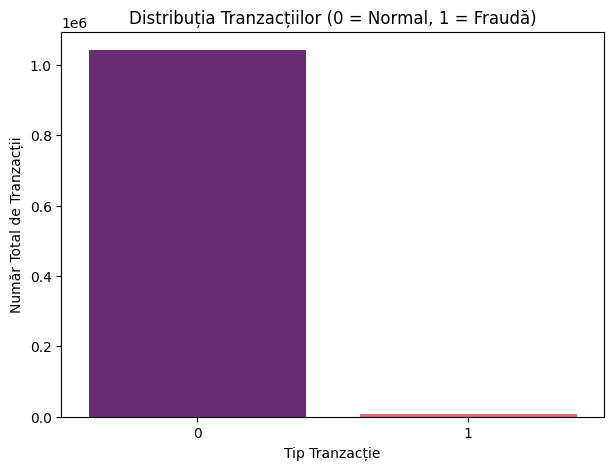

In [31]:

#  graficul "Count Plot"
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='is_fraud', palette='magma')

plt.title('Distribuția Tranzacțiilor (0 = Normal, 1 = Fraudă)')
plt.xlabel('Tip Tranzacție')
plt.ylabel('Număr Total de Tranzacții')
plt.show()
     
                                                                                                                    

 Se observă că majoritatea tranzacțiilor sunt normale (is_fraud = 0), iar doar o mică parte sunt fraude (is_fraud = 1). Acest dezechilibru este comun în seturile de date de fraudă și poate necesita tehnici speciale de preprocesare sau modelare pentru a gestiona corect această situație.                                                                                                                                                               

3.Transaction Amount Analysis: Normal vs. Fraud

Tipul de date pentru coloana amt este: float64
Media sumelor pe categorii:
is_fraud
0     93.925054
1    608.143529
Name: amt, dtype: float64


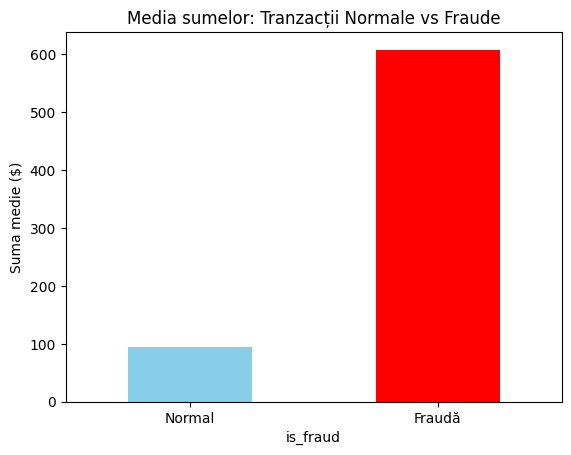

In [32]:


df['amt'] = pd.to_numeric(df['amt'].astype(str).str.replace(',', '.'), errors='coerce')

print("Tipul de date pentru coloana amt este:", df['amt'].dtype)
# media sumelor pentru ambele categorii
media_sume = df.groupby('is_fraud')['amt'].mean()
print("Media sumelor pe categorii:")
print(media_sume)

# grafic bar pentru a vedea diferența vizual
media_sume.plot(kind='bar', color=['skyblue', 'red'])
plt.title('Media sumelor: Tranzacții Normale vs Fraude')
plt.ylabel('Suma medie ($)')
plt.xticks([0, 1], ['Normal', 'Fraudă'], rotation=0)
plt.show()



 Se observă că media sumelor pentru tranzacțiile frauduloente este semnificativ mai mare decât pentru cele normale. Acest lucru indică faptul că fraudele implică în general sume mai mari.


4. Outlier Identification

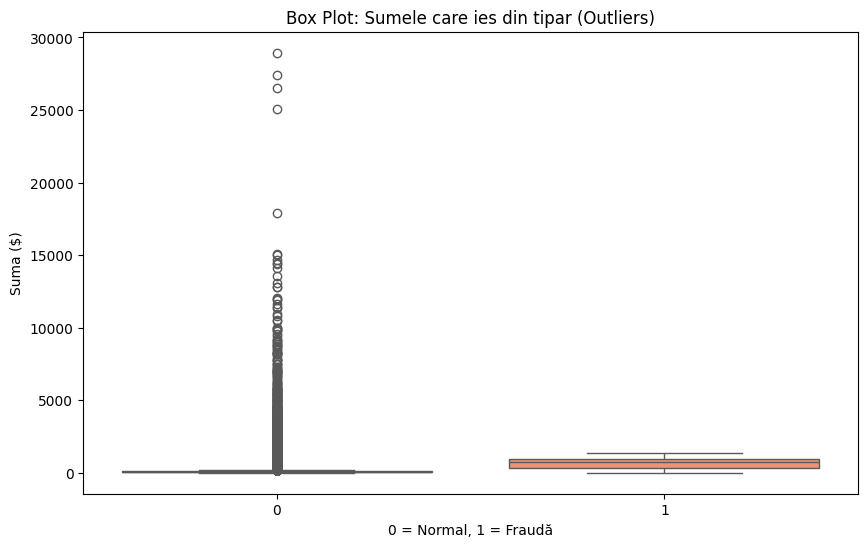

In [33]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_fraud', y='amt', palette='Set2')
plt.title('Box Plot: Sumele care ies din tipar (Outliers)')
plt.xlabel('0 = Normal, 1 = Fraudă')
plt.ylabel('Suma ($)')
plt.show()




 Boxplot-ul arată că există outliers semnificativi în ambele categorii, dar în special în categoria de fraude (is_fraud = 1). Acest lucru sugerează că unele tranzacții frauduloente implică sume extrem de mari, ceea ce poate fi un indiciu important pentru detectarea fraudelor.

5. Correlation Analysis: Latitude vs. Amount

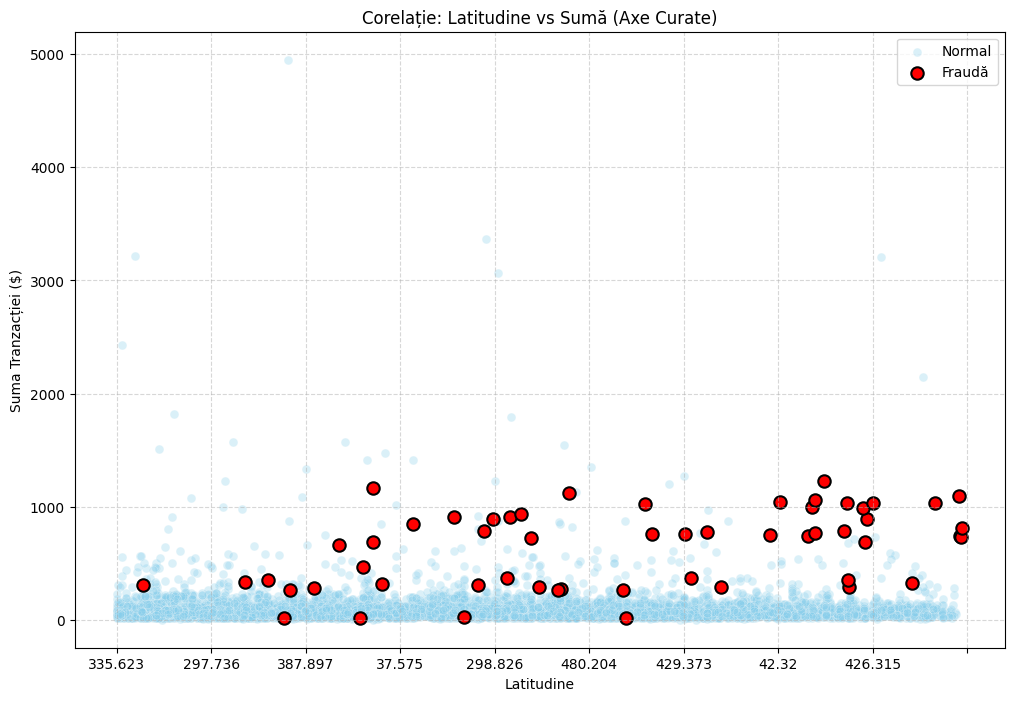

In [34]:

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 8))

df_sample = df.sample(10000)
sns.scatterplot(
    data=df_sample[df_sample['is_fraud'] == 0], 
    x='lat', y='amt', 
    color='skyblue', alpha=0.3, s=40, label='Normal'
)

sns.scatterplot(
    data=df_sample[df_sample['is_fraud'] == 1], 
    x='lat', y='amt', 
    color='red', alpha=1.0, s=80, 
    edgecolor='black', linewidth=1.5, label='Fraudă'
)

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(10)) 

plt.title('Corelație: Latitudine vs Sumă (Axe Curate)')
plt.xlabel('Latitudine')
plt.ylabel('Suma Tranzacției ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()




 Graficul de dispersie arată că tranzacțiile frauduloente (în roșu) tind să aibă sume mai mari și sunt răspândite pe o gamă largă de latitudini. Deși există o corelație vizuală între latitudine și sumă, nu este foarte puternică, ceea ce sugerează că alți factori ar putea juca un rol important în detectarea fraudelor.

6.Feature Correlation Matrix (Heatmap)

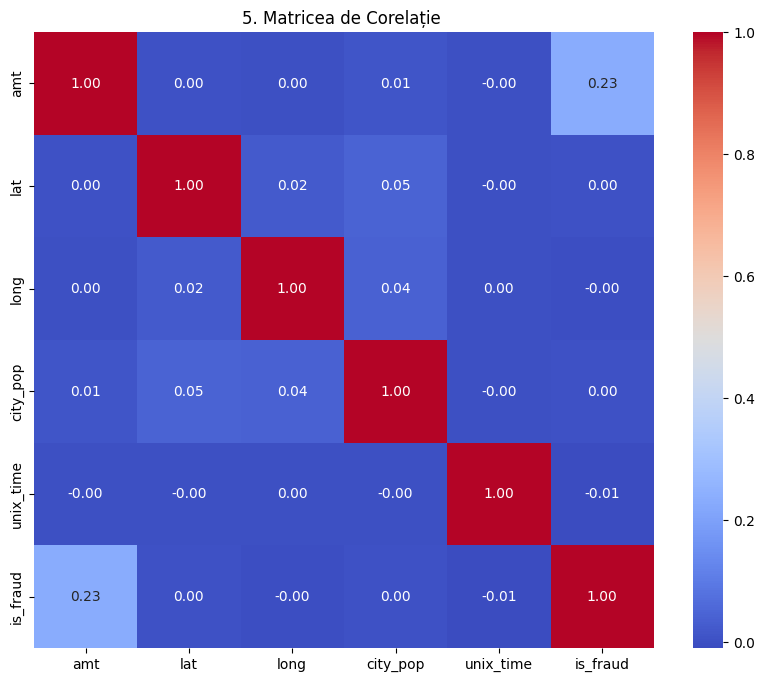

In [35]:

for col in ['lat', 'long']:
    
    df[col] = df[col].astype(str).str.replace(r'[^\d-]', '', regex=True)
    
    df[col] = pd.to_numeric(df[col], errors='coerce') / 10**6 

plt.figure(figsize=(10, 8))
numeric_df = df[['amt', 'lat', 'long', 'city_pop', 'unix_time', 'is_fraud']].dropna()
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('5. Matricea de Corelație ')
plt.show()


Heatmap-ul ne oferă o privire de ansamblu asupra relațiilor matematice dintre variabilele setului de date. Cea mai importantă observație este corelația pozitivă dintre coloana 'is_fraud' și 'amt' (suma tranzacției). Acest lucru confirmă ipoteza noastră anterioară: pe măsură ce suma tranzacției crește, crește și probabilitatea ca aceasta să fie o fraudă. Restul variabilelor, cum ar fi locația geografică sau populația orașului, prezintă o corelație foarte slabă sau inexistentă cu fenomenul de fraudă, ceea ce înseamnă că atacurile nu sunt limitate la o anumită zonă sau tip de oraș.